<a href="https://colab.research.google.com/github/MnNqB/bank-fraud-detection/blob/main/BankFraudModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r"/content/")

df = pd.read_csv("Base.csv")

In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['fraud_bool'].value_counts(normalize=True))

(1000000, 32)
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards   

# EDA

In [3]:
# Auto-separate column types
categoricals = df.select_dtypes(include='object').columns.tolist()
continuous = df.select_dtypes(include=['float64']).columns.tolist()
integers = [col for col in df.select_dtypes(include='int64').columns
            if col != 'fraud_bool' and df[col].nunique() > 10]
binary = [col for col in df.select_dtypes(include='int64').columns
          if col != 'fraud_bool' and df[col].nunique() <= 10]

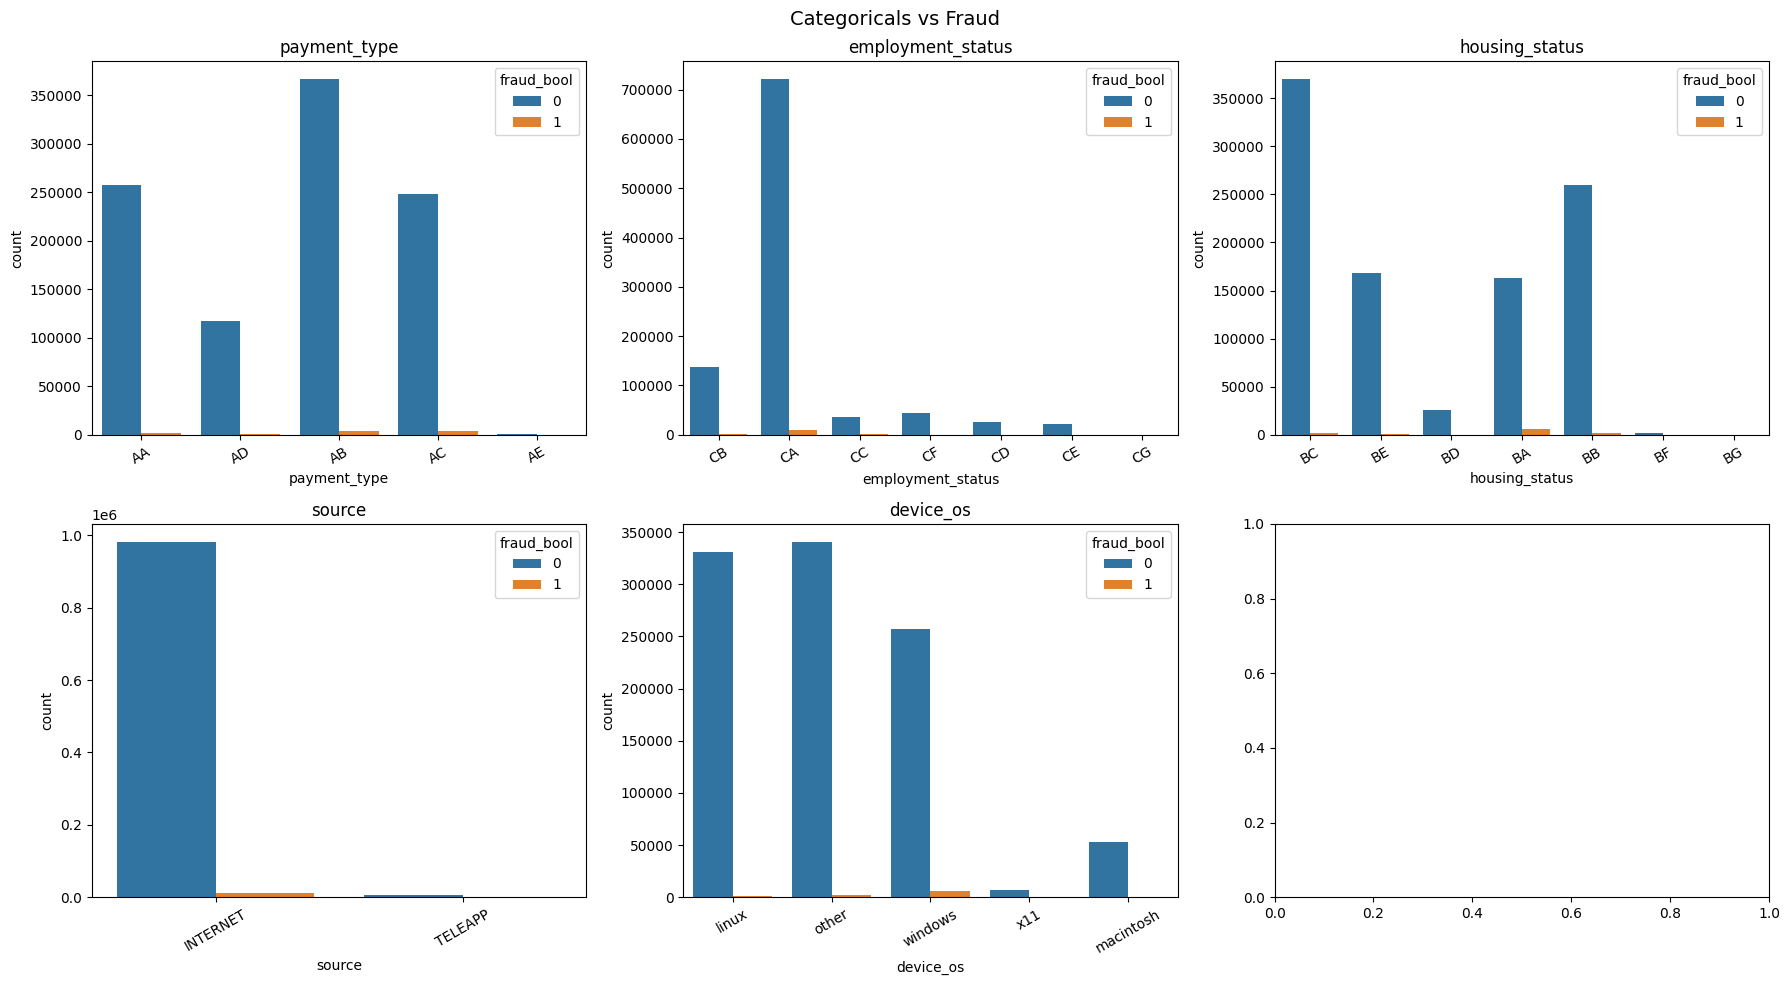

In [4]:
# 1. Categoricals — count plots split by fraud
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), categoricals):
    sns.countplot(data=df, x=col, hue='fraud_bool', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Categoricals vs Fraud', fontsize=14)
plt.tight_layout()
plt.show()

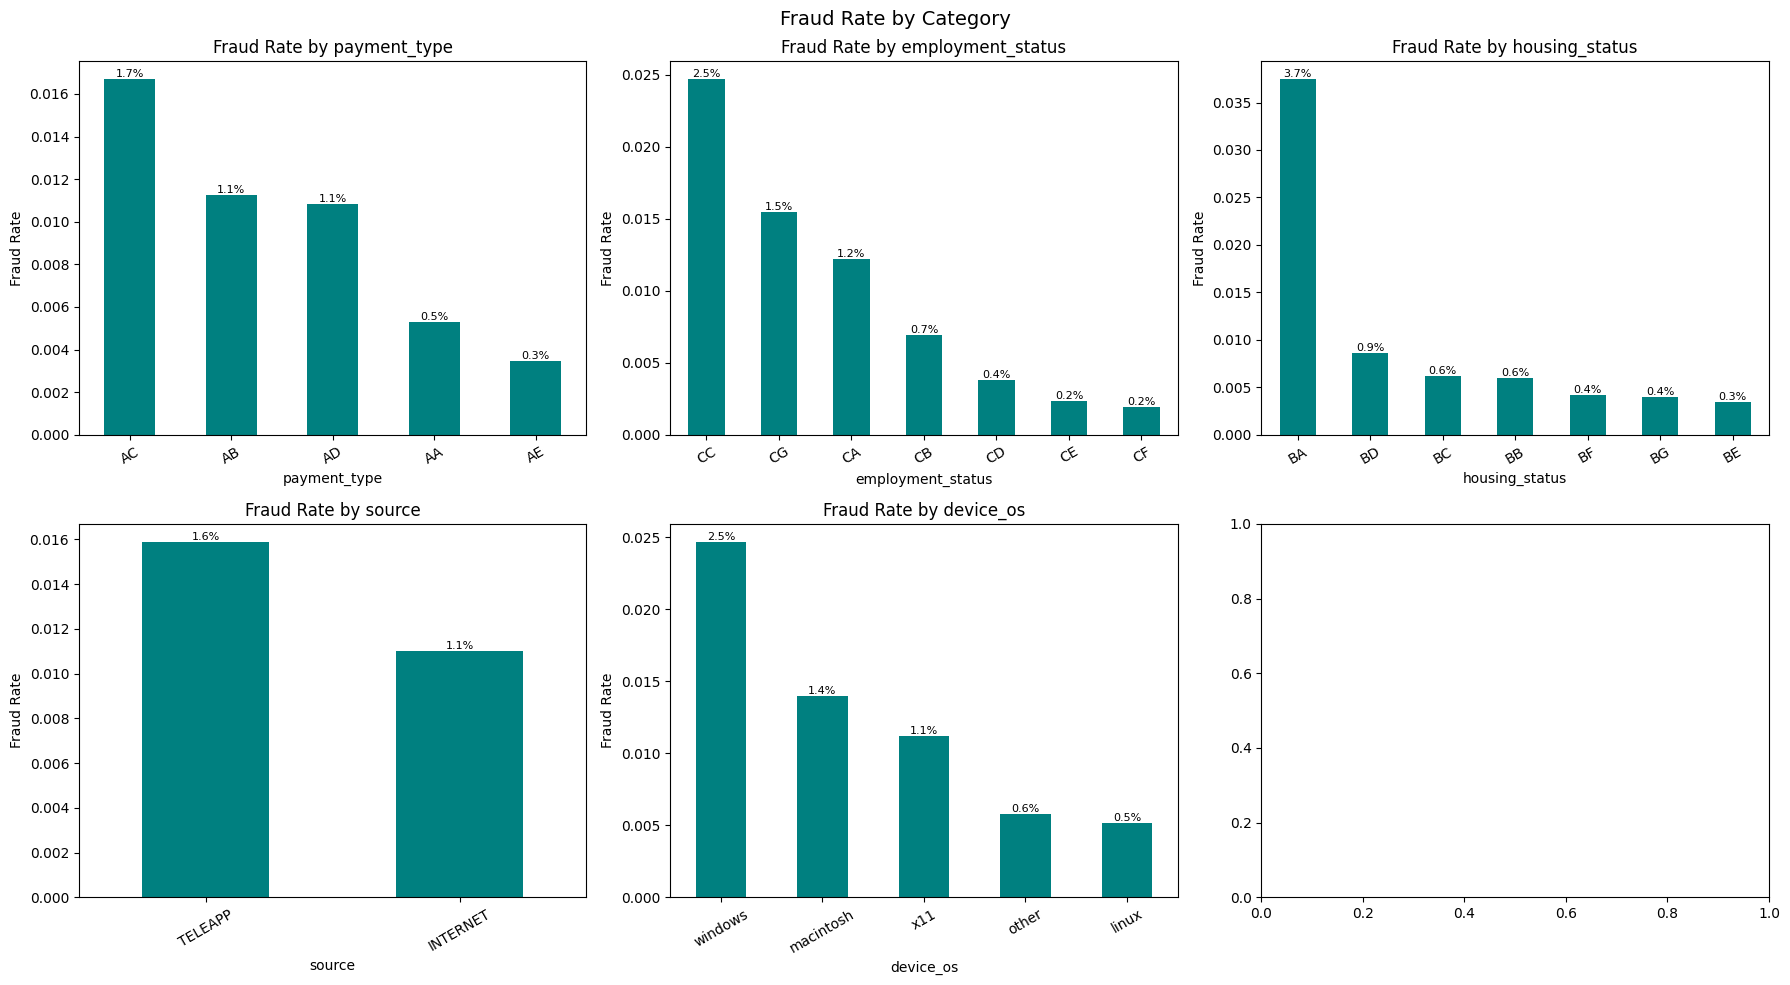

In [5]:
# 1.1 Categoricals — fraud rate per value
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), categoricals):
    fraud_rate = df.groupby(col)['fraud_bool'].mean().sort_values(ascending=False)
    fraud_rate.plot.bar(ax=ax, color='teal')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=30)
    # Add value labels on bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=8)
plt.suptitle('Fraud Rate by Category', fontsize=14)
plt.tight_layout()
plt.show()

## Categorical Features vs Fraud Rate

Plotting raw counts initially obscured the signal due to class imbalance — switching to **fraud rate per category** revealed clear patterns.

| Feature | High-Risk Category | Fraud Rate | vs Baseline (1.1%) |
|---|---|---|---|
| `housing_status` | `BA` | 3.7% | 4x |
| `employment_status` | `CC` | 2.5% | 2.3x |
| `device_os` | `Windows` | 2.5% | 2.3x |
| `source` | `TELEAPP` | 1.6% | 1.5x |

A few things worth noting:

- **Volume ≠ risk:** `employment_status` = `CA` dominated the count plot but has only a 1.2% fraud rate - a good reminder that raw counts are misleading under class imbalance
- **Linux is the safest OS:** Fraud rate of just 0.5% vs Windows at 2.5% - fraudsters disproportionately operate on Windows, possibly due to wider availability of fraud toolkits
- **TELEAPP is a moderate signal:** Higher fraud rate than INTERNET but with far fewer observations, so treat with some caution

These categorical signals motivated an interaction feature - see Feature Engineering below.

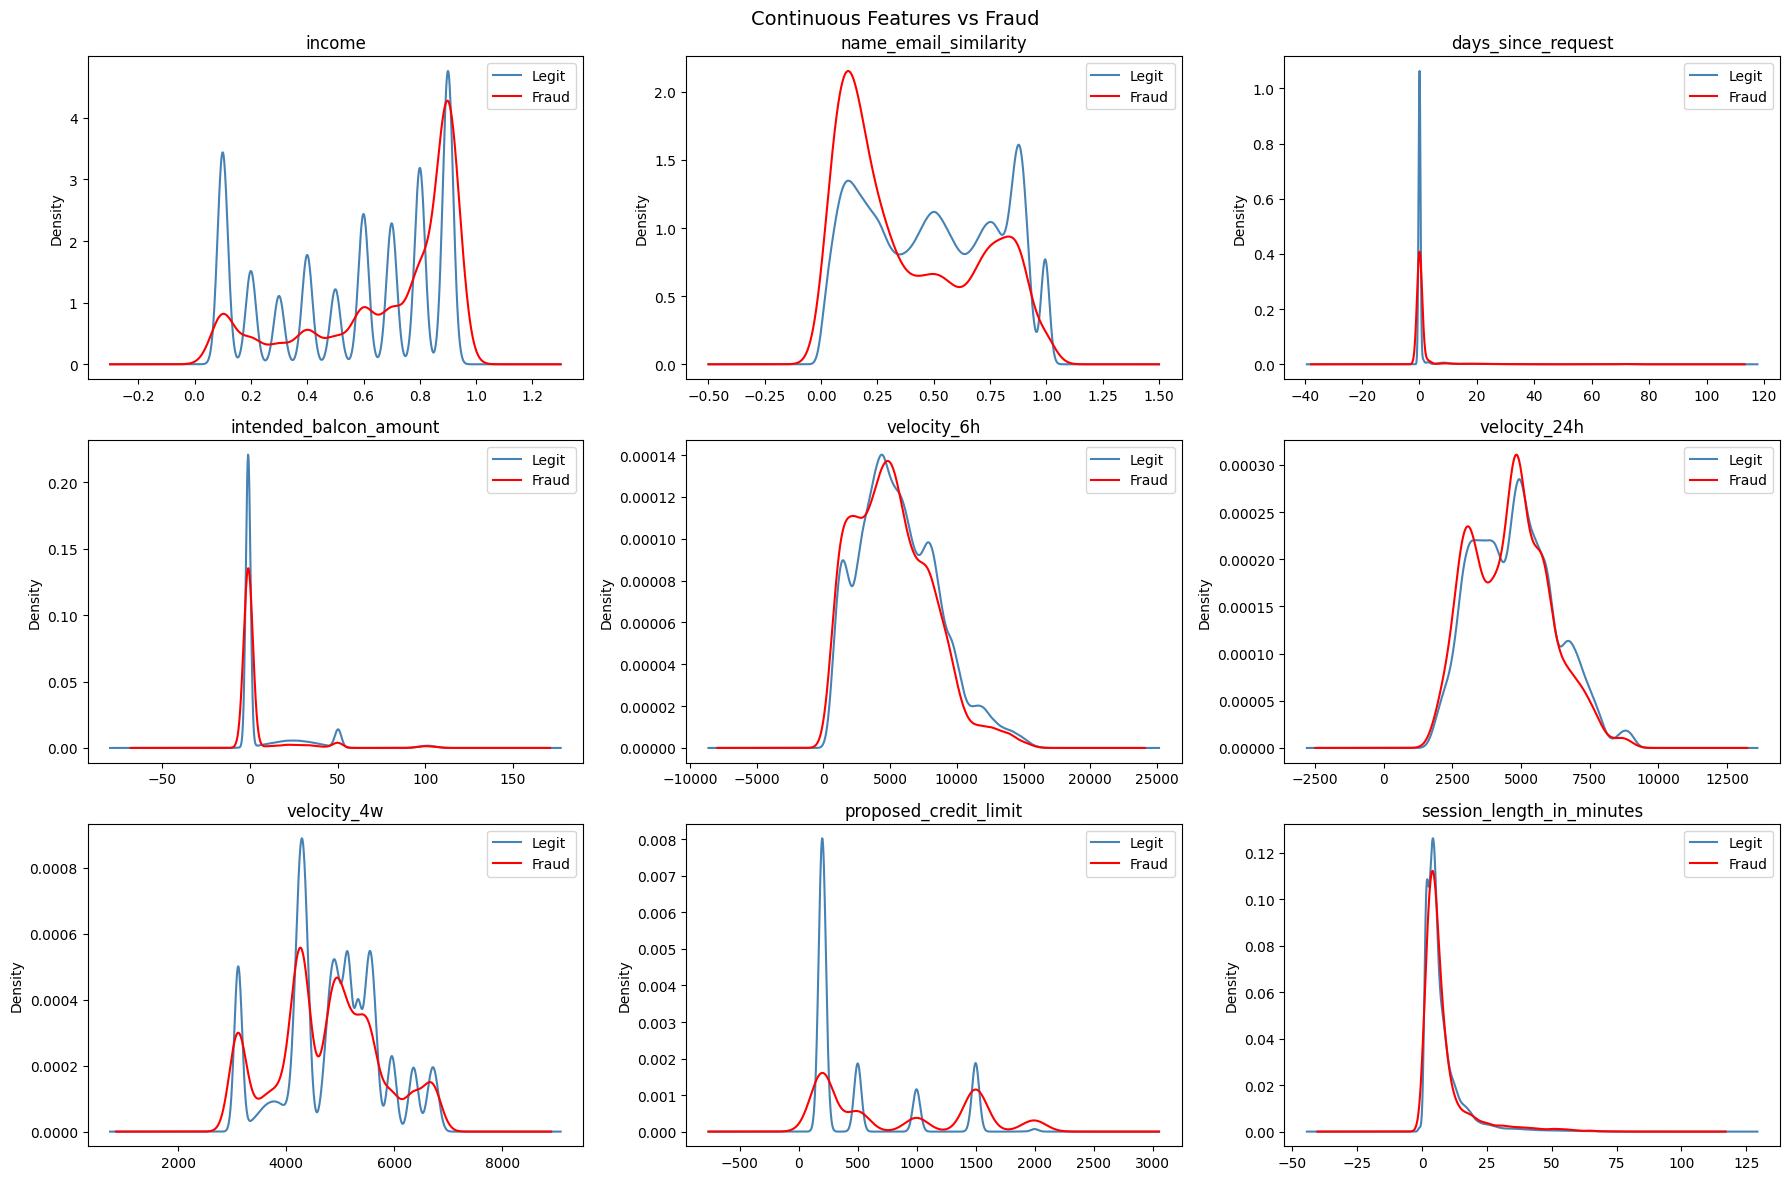

In [6]:
# 2. Continuous — KDE split by fraud (best for seeing separation)
# may take a bit to run - switch to sample only if needed
n = len(continuous)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, 4*((n+2)//3)))
for ax, col in zip(axes.flatten(), continuous):
    df[df.fraud_bool==0][col].plot.kde(ax=ax, label='Legit', color='steelblue')
    df[df.fraud_bool==1][col].plot.kde(ax=ax, label='Fraud', color='red')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Continuous Features vs Fraud', fontsize=14)
plt.tight_layout()
plt.show()

## Continuous Features vs Fraud Rate

KDE plots reveal distributional differences between fraudulent and legitimate applications.

### Strong Signals

| Feature | Pattern |
|---|---|
| `income` | Fraud peaks sharply at 0.9, legit is jagged and multimodal |
| `name_email_similarity` | Fraud spikes near 0, legit is more evenly spread |

- **`income`:** Legitimate applicants cluster at psychologically natural values — their
distribution is jagged and multimodal because real people report round salaries ($50k,
$75k, $100k). Fraudulent applications are suspiciously smooth, peaking hard at 0.9,
suggesting programmatic generation rather than real income reporting.

- **`name_email_similarity`:** Fraud spikes sharply near 0 — name and email share nothing
in common. This is a classic synthetic identity tell: a fabricated person paired with a
randomly generated email address. Legitimate applicants show a more spread distribution,
reflecting the natural variation in how real people set up email addresses.

### Key Insight: The Fabrication Signature

> Legitimate applicants cluster at psychologically natural values — round numbers,
> standard credit limits, recognizable income brackets. Fraudulent applications show
> artificially smooth distributions, consistent with programmatic generation rather
> than genuine human behavior.

This fabrication signature appears consistently across `income`, `proposed_credit_limit`,
and `name_email_similarity` — suggesting a common underlying generation process rather
than opportunistic individual fraud.

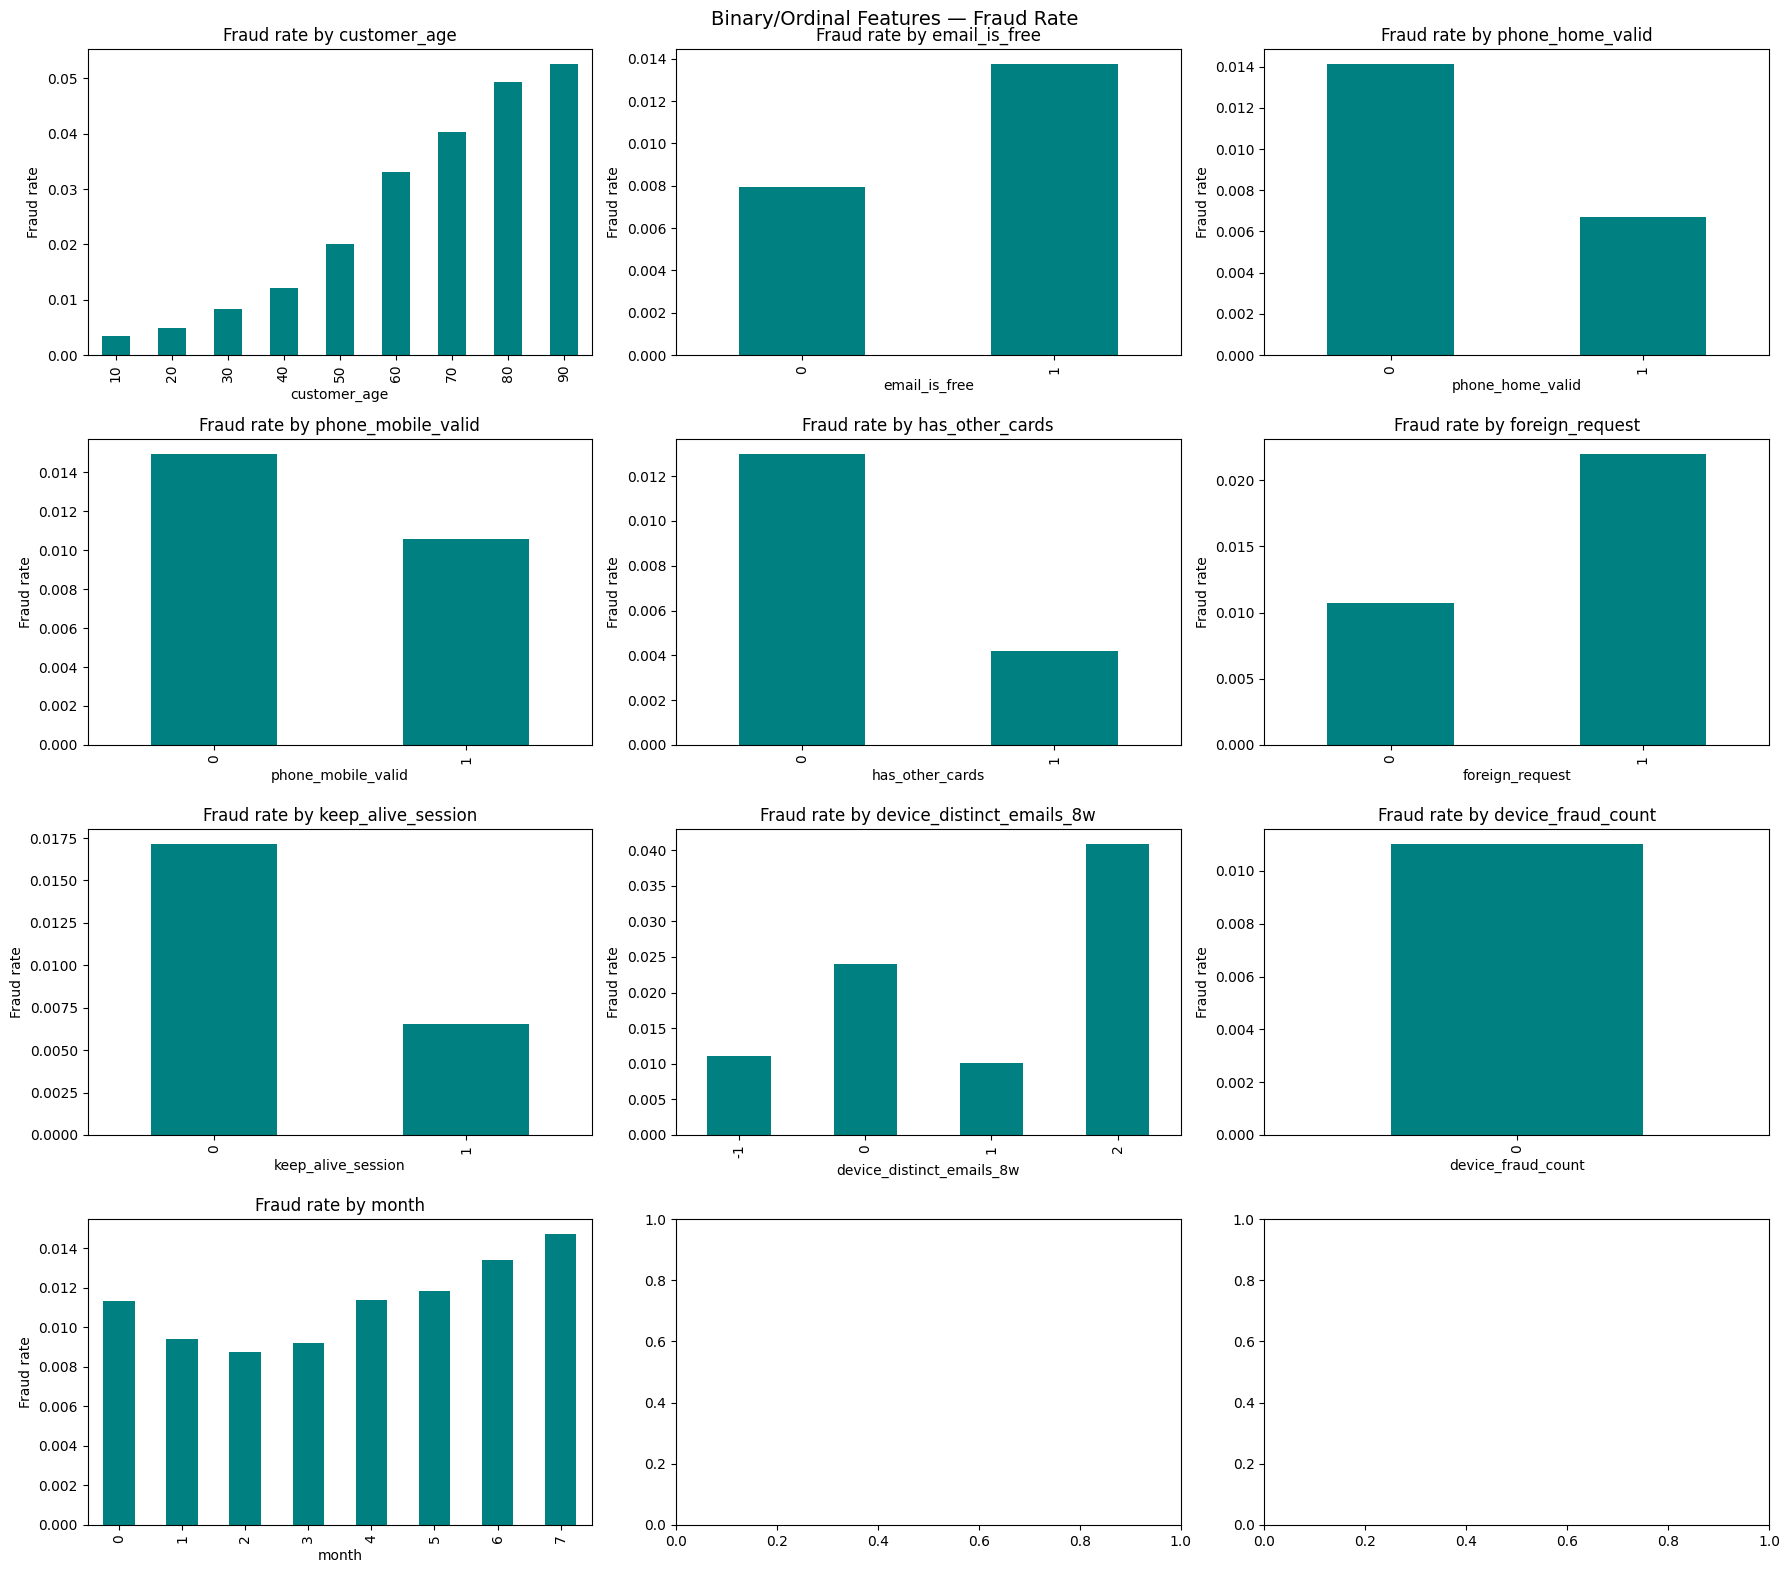

In [7]:
# 3. Binary/ordinal integers — fraud rate per value
n = len(binary)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, 4*((n+2)//3)))
for ax, col in zip(axes.flatten(), binary):
    df.groupby(col)['fraud_bool'].mean().plot.bar(ax=ax, color='teal')
    ax.set_title(f'Fraud rate by {col}')
    ax.set_ylabel('Fraud rate')
plt.suptitle('Binary/Ordinal Features — Fraud Rate', fontsize=14)
plt.tight_layout()
plt.show()

## Binary & Ordinal Features vs Fraud Rate

Fraud rate per category (rather than raw counts) reveals the clearest signals in this
feature group. Several features here align directly with known synthetic identity
fraud patterns.

### Very Strong Signals

| Feature | High-Risk Value | Fraud Rate | vs Baseline (1.1%) |
|---|---|---|---|
| `customer_age` | 90 | 5.5% | 5x |
| `device_distinct_emails_8w` | 2+ | 4.0% | 3.6x |
| `foreign_request` | 1 | 2.2% | 2x |
| `email_is_free` | 1 | 1.3% | 1.2x |

- **`customer_age`:** Fraud rate increases *monotonically* with age — nearly 0% at age
10, rising to 5.5% at age 90. This is a well-documented synthetic identity pattern:
fraudsters preferentially target elderly identities because they carry long credit
histories and are statistically less likely to actively monitor their accounts.

- **`device_distinct_emails_8w`:** A single device associated with 2 or more distinct
email addresses within 8 weeks reaches a 4% fraud rate — 3.6x baseline. This is a
strong behavioral signal: legitimate users rarely cycle through multiple identities
on the same device, but fraudsters frequently do. This feature directly motivated
engineering a `multi_email_device` binary flag.

- **`foreign_request`:** Double the baseline fraud rate at 2.2%. Foreign applications
are harder to verify against domestic identity databases, making them a natural
vector for synthetic identity fraud.

- **`email_is_free`:** Free email providers (Gmail, Yahoo, etc.) show higher fraud rates
than corporate or ISP emails — no institutional accountability, trivially easy to
create at scale.

### Key Insight: The Synthetic Identity Profile

Taken together, these features paint a coherent fraudster persona:

> An elderly identity, foreign origin, thin credit file with no other cards,
> free email that doesn't match the name, invalid contact numbers, submitted
> immediately from a Windows device that has cycled through multiple email
> addresses in recent weeks.

This is not a collection of independent signals — it is a consistent behavioral
and identity fabrication pattern, which is why interaction features between
these variables (see Feature Engineering) proved valuable.

In [12]:
### Train Test Split
from sklearn.model_selection import train_test_split

X = df.drop('fraud_bool',axis=1)
y = df['fraud_bool']

# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42, stratify=y)
# Temporal splitting as proposed in the BAF paper — training on months 0-5 and testing on 6-7 to simulate real production conditions where models always predict future fraud from historical patterns
X_train = X[X['month'] < 6].copy()
X_test  = X[X['month'] >= 6].copy()
y_train = y[X['month'] < 6].copy()
y_test  = y[X['month'] >= 6].copy()

X_train = X_train.drop('month', axis=1)
X_test  = X_test.drop('month', axis=1)

print(f"Train: {X_train.shape}, fraud rate: {y_train.mean():.3%}")
print(f"Test:  {X_test.shape},  fraud rate: {y_test.mean():.3%}")

Train: (794989, 30), fraud rate: 1.025%
Test:  (205011, 30),  fraud rate: 1.404%


### *Feature Engineering*

In [13]:
# phone_mobile_valid — same but flipped! Invalid mobile = higher fraud too
X_train['no_valid_phone'] = ((X_train['phone_home_valid'] == 0) & (X_train['phone_mobile_valid'] == 0)).astype(int)
X_test['no_valid_phone'] = ((X_test['phone_home_valid'] == 0) & (X_test['phone_mobile_valid'] == 0)).astype(int)
# Since we are exploring tree models - no need to drop original vars to avoid multi-collinearity. But would need to for linear models

# Is income in the fraud danger zone?
X_train['income_high'] = (X_train['income'] > 0.8).astype(int)
X_test['income_high'] = (X_test['income'] > 0.8).astype(int)

## Is income suspiciously round/high?
# X_train['income_is_round'] = (X_train['income'] % 0.1 < 0.01).astype(int)
# X_test['income_is_round'] = (X_test['income'] % 0.1 < 0.01).astype(int)

## Engineered a round-income flag based on fraud psychology — humans pick round salaries.
## However, since BAF income is pre-normalized to 0-1, the signal inverted and
## the feature was dropped. Fraud rate for round vs non-round income
# print(X_train.join(y_train).groupby('income_is_round')['fraud_bool'].mean())
# X_train.drop('income_is_round', axis=1, inplace=True)
# X_test.drop('income_is_round', axis=1, inplace=True)

# Is immediate request flag
X_train['is_immediate'] = (X_train['days_since_request'] < 1).astype(int)
X_test['is_immediate'] = (X_test['days_since_request'] < 1).astype(int)

X_train['multi_email_device'] = (X_train['device_distinct_emails_8w'] >= 2).astype(int)
X_test['multi_email_device'] = (X_test['device_distinct_emails_8w'] >= 2).astype(int)

# Target encoding - Housing + OS interaction
# Part 1 - build the map
housing_os_map = (
    X_train.join(y_train).groupby(['housing_status', 'device_os'])['fraud_bool'].mean()
    .reset_index()
    .rename(columns={'fraud_bool': 'housing_os_fraud_rate'}))

# Part 2 - merge it in
X_train = X_train.merge(housing_os_map, on=['housing_status', 'device_os'], how='left')
X_test  = X_test.merge(housing_os_map, on=['housing_status', 'device_os'], how='left')

# Handle any unseen combinations in test
X_test['housing_os_fraud_rate'] = X_test['housing_os_fraud_rate'].fillna(
    housing_os_map['housing_os_fraud_rate'].mean())

In [14]:
# --- One-hot encode categoricals ---
X_train = pd.get_dummies(X_train, columns=categoricals, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categoricals, drop_first=True)

# Align columns in case test is missing any dummy category
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nFinal feature count: {X_train.shape[1]}")

### Sanity check
# Make sure test has same columns as train
print("Any columns mismatch:", set(X_train.columns) != set(X_test.columns))


Final feature count: 51
Any columns mismatch: False


In [15]:
# Check no nulls crept in from the target encoding merge
print(f"\nNulls in train: {X_train.isnull().sum().sum()}")
print(f"Nulls in test:  {X_test.isnull().sum().sum()}")


Nulls in train: 0
Nulls in test:  0


### Modeling

In [17]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, PrecisionRecallDisplay


# LR needs scaling unlike tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## since we haven't dropped original features - will run into multicollinearity
# lr = LogisticRegression(
#     class_weight='balanced',
#     max_iter=1000,
#     random_state=42,
#     n_jobs=-1
# )

lr = LogisticRegression(
    class_weight='balanced',
    penalty='l2',      # default, handles multicollinearity
    C=0.1,             # stronger regularization
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"AUPRC:   {average_precision_score(y_test, y_prob_lr):.4f}")

ROC-AUC: 0.8796
AUPRC:   0.1630


Best threshold: 0.8784
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.99    202133
       Fraud       0.20      0.31      0.24      2878

    accuracy                           0.97    205011
   macro avg       0.60      0.65      0.61    205011
weighted avg       0.98      0.97      0.98    205011



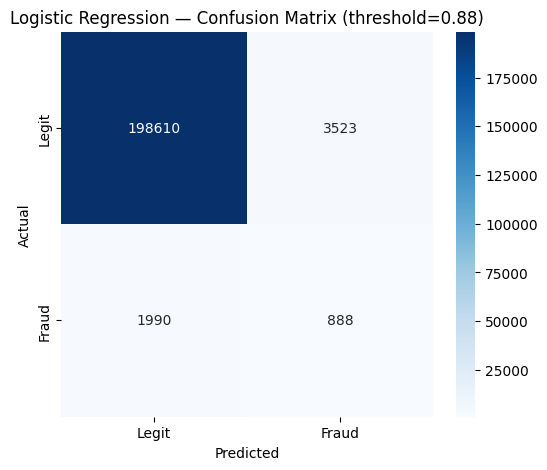

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import numpy as np

# Find best F1 threshold
precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test, y_prob_lr)
f1_scores_lr = 2 * (precisions_lr[:-1] * recalls_lr[:-1]) / (precisions_lr[:-1] + recalls_lr[:-1] + 1e-8)
best_idx_lr = np.argmax(f1_scores_lr)
best_thresh_lr = thresholds_lr[best_idx_lr]

print(f"Best threshold: {best_thresh_lr:.4f}")

# Predictions at best threshold
y_pred_lr = (y_prob_lr > best_thresh_lr).astype(int)

# Classification report
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Logistic Regression — Confusion Matrix (threshold={best_thresh_lr:.2f})')
plt.show()

In [20]:
# XGBoost
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's version of class_weight='balanced'
scale = int((y_train==0).sum() / y_train.sum())
print(f"scale_pos_weight: {scale}")

xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale,   # handles imbalance
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',      # optimize for AUPRC directly
    verbosity=1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"AUPRC:   {average_precision_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight: 96
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    202133
           1       0.07      0.75      0.13      2878

    accuracy                           0.86    205011
   macro avg       0.53      0.80      0.53    205011
weighted avg       0.98      0.86      0.91    205011

ROC-AUC: 0.8878
AUPRC:   0.1790


Text(0.5, 1.0, 'Precision-Recall Curve')

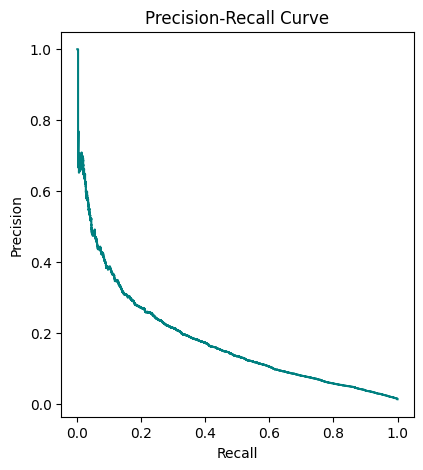

In [21]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 5))

# Left plot - PR curve
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, color='teal')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

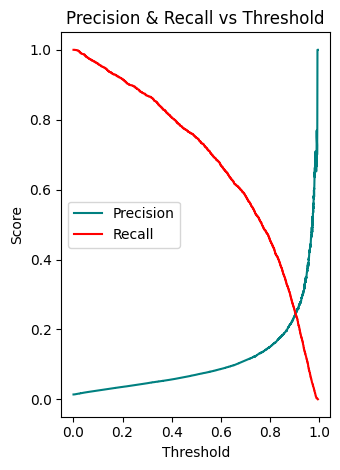

In [22]:
# Right plot - precision & recall vs threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision', color='teal')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Find crossover point
crossover_idx = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))
print(f"Crossover threshold: {thresholds[crossover_idx]:.4f}")
print(f"  Precision: {precisions[crossover_idx]:.4f}")
print(f"  Recall:    {recalls[crossover_idx]:.4f}")

# Find threshold that maximizes F1
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_f1_idx = np.argmax(f1_scores)
print(f"\nBest F1 threshold: {thresholds[best_f1_idx]:.4f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  Recall:    {recalls[best_f1_idx]:.4f}")
print(f"  F1:        {f1_scores[best_f1_idx]:.4f}")

# Evaluate at best F1 threshold
y_pred_xgb_best = (y_prob_xgb > thresholds[best_f1_idx]).astype(int)
print(f"\nClassification report at best F1 threshold:")
print(classification_report(y_test, y_pred_xgb_best))


Crossover threshold: 0.9048
  Precision: 0.2439
  Recall:    0.2439

Best F1 threshold: 0.8801
  Precision: 0.2128
  Recall:    0.3072
  F1:        0.2514

Classification report at best F1 threshold:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    202133
           1       0.21      0.31      0.25      2878

    accuracy                           0.97    205011
   macro avg       0.60      0.65      0.62    205011
weighted avg       0.98      0.97      0.98    205011



In [24]:
# LightGBM
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    scale_pos_weight=scale,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # suppress output
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(f"AUPRC:   {average_precision_score(y_test, y_prob_lgbm):.4f}")

              precision    recall  f1-score   support

           0       1.00      0.83      0.90    202133
           1       0.06      0.80      0.11      2878

    accuracy                           0.83    205011
   macro avg       0.53      0.81      0.51    205011
weighted avg       0.98      0.83      0.89    205011

ROC-AUC: 0.8886
AUPRC:   0.1865


In [25]:
# Find best F1 threshold for LightGBM
precisions_l, recalls_l, thresholds_l = precision_recall_curve(y_test, y_prob_lgbm)
f1_scores_l = 2 * (precisions_l[:-1] * recalls_l[:-1]) / (precisions_l[:-1] + recalls_l[:-1] + 1e-8)
best_idx_l = np.argmax(f1_scores_l)
best_thresh_l = thresholds_l[best_idx_l]

y_pred_lgbm_best = (y_prob_lgbm > best_thresh_l).astype(int)

print(f"Best threshold: {best_thresh_l:.4f}")
print(classification_report(y_test, y_pred_lgbm_best))
print(f"AUPRC: {average_precision_score(y_test, y_prob_lgbm):.4f}")

Best threshold: 0.8962
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    202133
           1       0.22      0.33      0.26      2878

    accuracy                           0.97    205011
   macro avg       0.60      0.66      0.63    205011
weighted avg       0.98      0.97      0.98    205011

AUPRC: 0.1865


In [27]:
# Full model comparison table
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'Logistic Regression': (y_prob_lr, y_pred_lr),
    'XGBoost':             (y_prob_xgb, y_pred_xgb_best),
    'LightGBM':            (y_prob_lgbm, y_pred_lgbm_best),
}

print("="*70)
print(f"{'Metric':<25} {'Log Reg':>12} {'XGBoost':>12} {'LightGBM':>12}")
print("="*70)

metrics = {
    'AUPRC':           lambda p, y: average_precision_score(y_test, p),
    'ROC-AUC':         lambda p, y: roc_auc_score(y_test, p),
    'Fraud Precision': lambda p, y: precision_score(y_test, y),
    'Fraud Recall':    lambda p, y: recall_score(y_test, y),
    'Fraud F1':        lambda p, y: f1_score(y_test, y),
}

for metric_name, func in metrics.items():
    row = f"{metric_name:<25}"
    for probs, preds in models.values():
        row += f" {func(probs, preds):>12.4f}"
    print(row)

print("="*70)

Metric                         Log Reg      XGBoost     LightGBM
AUPRC                           0.1630       0.1790       0.1865
ROC-AUC                         0.8796       0.8878       0.8886
Fraud Precision                 0.2013       0.2126       0.2192
Fraud Recall                    0.3085       0.3068       0.3339
Fraud F1                        0.2437       0.2511       0.2647


Best model so far is LightGBM

### LightGBM Hyperparameter Tuning

In [28]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.0 MB/s eta 0:00:00


In [29]:
import optuna
from sklearn.metrics import average_precision_score
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noisy output

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  scale,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    return average_precision_score(y_test, y_prob)  # maximize AUPRC


# Run optimization — 50 trials is a good balance of speed vs thoroughness
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUPRC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUPRC: 0.1986
Best params: {'n_estimators': 933, 'learning_rate': 0.029644058948362296, 'max_depth': 3, 'num_leaves': 138, 'min_child_samples': 14, 'subsample': 0.7421554303401763, 'colsample_bytree': 0.5261097279547831, 'reg_alpha': 5.184522747915301, 'reg_lambda': 1.390981809616324}


In [30]:
# Retrain with best params
best_params = study.best_params
best_params['scale_pos_weight'] = scale
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

lgbm_tuned = LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train, y_train)

y_prob_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]

# Find best threshold
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_test, y_prob_tuned)
f1s_t = 2 * (precisions_t[:-1] * recalls_t[:-1]) / (precisions_t[:-1] + recalls_t[:-1] + 1e-8)
best_thresh_tuned = thresholds_t[np.argmax(f1s_t)]
y_pred_tuned = (y_prob_tuned > best_thresh_tuned).astype(int)

print(f"Best threshold: {best_thresh_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))
print(f"AUPRC:   {average_precision_score(y_test, y_prob_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

Best threshold: 0.9099
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.99    202133
       Fraud       0.23      0.33      0.27      2878

    accuracy                           0.98    205011
   macro avg       0.61      0.66      0.63    205011
weighted avg       0.98      0.98      0.98    205011

AUPRC:   0.1986
ROC-AUC: 0.8949


### SMOTE

In [31]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.1)
# 0.1 = make fraud 10% of training data, not 50/50
# going full 50/50 often hurts — too many synthetic samples

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

# Train tuned LightGBM on SMOTE data
lgbm_smote = LGBMClassifier(**best_params)
lgbm_smote.fit(X_train_sm, y_train_sm)

y_prob_smote = lgbm_smote.predict_proba(X_test)[:, 1]

# Threshold
precisions_s, recalls_s, thresholds_s = precision_recall_curve(y_test, y_prob_smote)
f1s_s = 2 * (precisions_s[:-1] * recalls_s[:-1]) / (precisions_s[:-1] + recalls_s[:-1] + 1e-8)
best_thresh_smote = thresholds_s[np.argmax(f1s_s)]
y_pred_smote = (y_prob_smote > best_thresh_smote).astype(int)

print(classification_report(y_test, y_pred_smote, target_names=['Legit', 'Fraud']))
print(f"AUPRC:   {average_precision_score(y_test, y_prob_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_smote):.4f}")

Before SMOTE: {0: 786838, 1: 8151}
After SMOTE:  {0: 786838, 1: 78683}
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.99    202133
       Fraud       0.22      0.31      0.26      2878

    accuracy                           0.97    205011
   macro avg       0.60      0.65      0.62    205011
weighted avg       0.98      0.97      0.98    205011

AUPRC:   0.1862
ROC-AUC: 0.8876


SMOTE degraded performance on this dataset, likely because the large sample size and scale_pos_weight already compensate for imbalance effectively. Synthetic oversampling introduced noise rather than signal.

### Final Model Comparison

In [32]:
print("="*75)
print(f"{'Metric':<25} {'LR':>10} {'XGBoost':>10} {'LGBM':>10} {'LGBM Tuned':>12}")
print("="*75)

models_final = {
    'LR':         (y_prob_lr,    y_pred_lr),
    'XGBoost':    (y_prob_xgb,   y_pred_xgb_best),
    'LGBM':       (y_prob_lgbm,  y_pred_lgbm_best),
    'LGBM Tuned': (y_prob_tuned, y_pred_tuned),
}

metrics = {
    'AUPRC':           lambda p, y: average_precision_score(y_test, p),
    'ROC-AUC':         lambda p, y: roc_auc_score(y_test, p),
    'Fraud Precision': lambda p, y: precision_score(y_test, y),
    'Fraud Recall':    lambda p, y: recall_score(y_test, y),
    'Fraud F1':        lambda p, y: f1_score(y_test, y),
}

for metric_name, func in metrics.items():
    row = f"{metric_name:<25}"
    for probs, preds in models_final.values():
        row += f" {func(probs, preds):>12.4f}"
    print(row)

print("="*75)

Metric                            LR    XGBoost       LGBM   LGBM Tuned
AUPRC                           0.1630       0.1790       0.1865       0.1986
ROC-AUC                         0.8796       0.8878       0.8886       0.8949
Fraud Precision                 0.2013       0.2126       0.2192       0.2318
Fraud Recall                    0.3085       0.3068       0.3339       0.3350
Fraud F1                        0.2437       0.2511       0.2647       0.2740


## SHAP Analysis

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


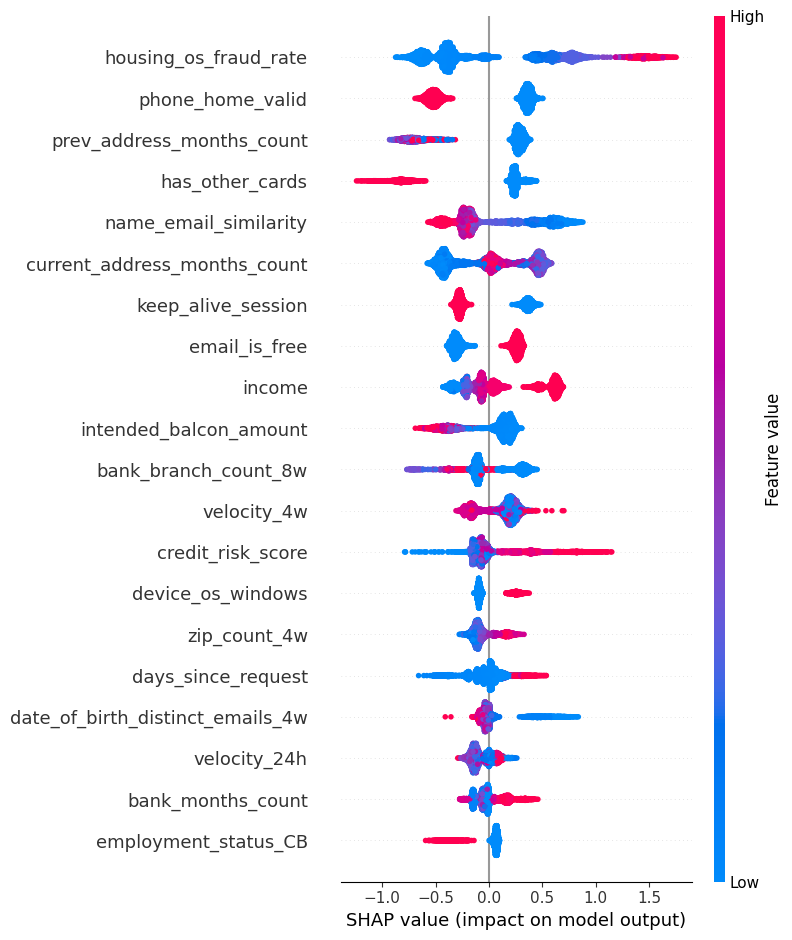

In [33]:
import shap

# Sample for speed
X_test_sample = X_test.sample(5000, random_state=42)

# TreeExplainer is optimized for LightGBM
explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — shows feature importance + direction
shap.summary_plot(shap_values, X_test_sample, max_display=20)
plt.show()

## SHAP Analysis — What Drives Fraud Predictions?

### Top Finding: Engineered Feature Dominates
`housing_os_fraud_rate` — the interaction feature engineered from
housing status × device OS — is the single strongest predictor,
outperforming all 51 original features. This validates the hypothesis
that certain housing situations combined with specific devices create
a disproportionate fraud risk.

### The Synthetic Identity Fingerprint
The model has learned a coherent fraud profile:

**Fraud indicators (push score up):**
- High income suspiciously close to 1.0
- Free email with low name similarity
- No other cards (thin-file)
- Windows device
- Multiple DOB/email combinations on same device

**Legitimacy indicators (push score down):**
- Valid home phone number
- Long address history (prev + current)
- Established banking relationship
- Higher credit risk score paradoxically reduces fraud
  (real people have credit histories)

In [34]:
import joblib

joblib.dump(lgbm_tuned, 'lgbm_fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')  # needed for the demo

# save feature names for the demo app
import json
with open('feature_names.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)

print("Model saved!")

Model saved!
